In [119]:
# 1.
# Cykeltillverkningsföretag som heter Adventure Works Cycles. Företaget säljer cyklar, delar och tillbehör till
# detalj- och grossistkunder och hanterar försäljningskanaler online och offline. Datamodellen innehåller tabeller för: 
# (Person, HumanResources, Production, Purchasing and Sales)

In [22]:
! pip install sqlalchemy
! pip install pyodbc

In [23]:
from sqlalchemy import create_engine, MetaData, Table, inspect
import pandas as pd
import matplotlib.pyplot as plt
import pyodbc

In [24]:
def new_engine(dialect, server, database, user=None, password=None, integrated_security=True):
    if integrated_security:
        eng = f"{dialect}://{server}/{database}?trusted_connection=yes&driver=ODBC+Driver+17+for+SQL+Server"
    else:
        eng = f"{dialect}://{user}:{password}@{server}/{database}?driver=ODBC+Driver+17+for+SQL+Server"
    print(eng)
    return create_engine(eng)

In [25]:
engine = new_engine('mssql', 'LAPTOP-68GNTQ05', 'AdventureWorks2022', integrated_security=True)

mssql://LAPTOP-68GNTQ05/AdventureWorks2022?trusted_connection=yes&driver=ODBC+Driver+17+for+SQL+Server


In [26]:
print(type(engine))

<class 'sqlalchemy.engine.base.Engine'>


In [27]:
connection = engine.connect()

In [28]:
print(type(connection))

<class 'sqlalchemy.engine.base.Connection'>


In [29]:
inspector = inspect(engine)
schemas = inspector.get_schema_names()
print(schemas)

['db_accessadmin', 'db_backupoperator', 'db_datareader', 'db_datawriter', 'db_ddladmin', 'db_denydatareader', 'db_denydatawriter', 'db_owner', 'db_securityadmin', 'dbo', 'guest', 'HumanResources', 'INFORMATION_SCHEMA', 'Person', 'Production', 'Purchasing', 'Sales', 'sys']


In [30]:
for schema in schemas:
    print(schema)

db_accessadmin
db_backupoperator
db_datareader
db_datawriter
db_ddladmin
db_denydatareader
db_denydatawriter
db_owner
db_securityadmin
dbo
guest
HumanResources
INFORMATION_SCHEMA
Person
Production
Purchasing
Sales
sys


In [31]:
print(inspector.get_table_names(schema='Sales'))

['CountryRegionCurrency', 'CreditCard', 'Currency', 'CurrencyRate', 'Customer', 'PersonCreditCard', 'SalesOrderDetail', 'SalesOrderHeader', 'SalesOrderHeaderSalesReason', 'SalesPerson', 'SalesPersonQuotaHistory', 'SalesReason', 'SalesTaxRate', 'SalesTerritory', 'SalesTerritoryHistory', 'ShoppingCartItem', 'SpecialOffer', 'SpecialOfferProduct', 'Store']


In [34]:
for col in inspector.get_columns(table_name='SalesPerson', schema='Sales'):
    print(col['name'])

BusinessEntityID
TerritoryID
SalesQuota
Bonus
CommissionPct
SalesYTD
SalesLastYear
rowguid
ModifiedDate


In [47]:
df = pd.read_sql(sql="SELECT * from Sales.SalesPerson", con=connection)

In [48]:
df.head(20)

,BusinessEntityID,TerritoryID,SalesQuota,Bonus,CommissionPct,SalesYTD,SalesLastYear,rowguid,ModifiedDate
0,274,NaN,NaN,0.0,0.000,5.596976e+05,0.000000e+00,48754992-9EE0-4C0E-8C94-9451604E3E02,2010-12-28
1,275,2.0,300000.0,4100.0,0.012,3.763178e+06,1.750406e+06,1E0A7274-3064-4F58-88EE-4C6586C87169,2011-05-24
2,276,4.0,250000.0,2000.0,0.015,4.251369e+06,1.439156e+06,4DD9EEE4-8E81-4F8C-AF97-683394C1F7C0,2011-05-24
3,277,3.0,250000.0,2500.0,0.015,3.189418e+06,1.997186e+06,39012928-BFEC-4242-874D-423162C3F567,2011-05-24
4,278,6.0,250000.0,500.0,0.010,1.453719e+06,1.620277e+06,7A0AE1AB-B283-40F9-91D1-167ABF06D720,2011-05-24
5,279,5.0,300000.0,6700.0,0.010,2.315186e+06,1.849641e+06,52A5179D-3239-4157-AE29-17E868296DC0,2011-05-24
6,280,1.0,250000.0,5000.0,0.010,1.352577e+06,1.927059e+06,BE941A4A-FB50-4947-BDA4-BB8972365B08,2011-05-24
7,281,4.0,250000.0,3550.0,0.010,2.458536e+06,2.073506e+06,35326DDB-7278-4FEF-B3BA-EA137B69094E,2011-05-24
8,282,6.0,250000.0,5000.0,0.015,2.604541e+06,2.038235e+06,31FD7FC1-DC84-4F05-B9A0-762519EACACC,2011-05-24
9,283,1.0,250000.0,3500.0,0.012,1.573013e+06,1.371635e+06,6BAC15B2-8FFB-45A9-B6D5-040E16C2073F,2011-05-24


In [76]:
# Ska kolla alla bästa 5 säljare i företaget.

query_top5_sellers = """
SELECT TOP 5
    sp.BusinessEntityID,
    p.FirstName,
    p.LastName,
    sp.SalesYTD,
    sp.SalesLastYear
FROM Sales.SalesPerson sp
JOIN Person.Person p ON sp.BusinessEntityID = p.BusinessEntityID
ORDER BY sp.SalesYTD DESC
"""
df = pd.read_sql(sql=query_top5_sellers, con=connection)
df.head(5)


,BusinessEntityID,FirstName,LastName,SalesYTD,SalesLastYear
0,276,Linda,Mitchell,4.251369e+06,1.439156e+06
1,289,Jae,Pak,4.116871e+06,1.635823e+06
2,275,Michael,Blythe,3.763178e+06,1.750406e+06
3,277,Jillian,Carson,3.189418e+06,1.997186e+06
4,290,Ranjit,Varkey Chudukatil,3.121616e+06,2.396540e+06


In [77]:
# Ska kolla på topp 10 mest sålda produkter (efter kvantitet).

query_top10_products = """
SELECT TOP 10
    p.Name AS ProductName,
    SUM(sod.OrderQty) AS TotalQuantitySold
FROM Sales.SalesOrderDetail sod
JOIN Sales.SalesOrderHeader soh
    ON sod.SalesOrderID = soh.SalesOrderID
JOIN Production.Product p
    ON sod.ProductID = p.ProductID
GROUP BY
    p.Name
ORDER BY
    TotalQuantitySold DESC
"""
df = pd.read_sql(sql=query_top10_products, con=connection)
df.head(10)


,ProductName,TotalQuantitySold
0,AWC Logo Cap,8311
1,Water Bottle - 30 oz.,6815
2,"Sport-100 Helmet, Blue",6743
3,"Long-Sleeve Logo Jersey, L",6592
4,"Sport-100 Helmet, Black",6532
5,"Sport-100 Helmet, Red",6266
6,"Classic Vest, S",4247
7,Patch Kit/8 Patches,3865
8,"Short-Sleeve Classic Jersey, XL",3864
9,"Long-Sleeve Logo Jersey, M",3636


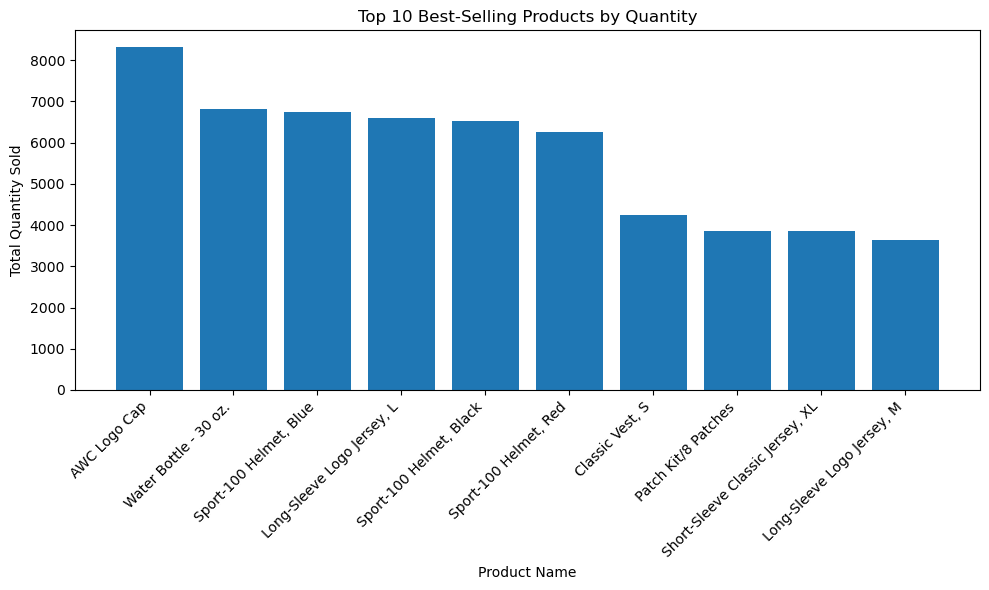

In [72]:
plt.figure(figsize=(10, 6))  
plt.bar(df['ProductName'], df['TotalQuantitySold'])
plt.title("Top 10 Best-Selling Products by Quantity")
plt.xlabel("Product Name")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [87]:
# Månadsförsäljning per territorium.

query_monthly_sales_territory = """
SELECT
    st.Name AS Territory,
    DATENAME(YEAR, soh.OrderDate) AS SalesYear,
    DATENAME(MONTH, soh.OrderDate) AS SalesMonth,
    SUM(soh.SubTotal) AS TotalSales
FROM Sales.SalesOrderHeader soh
JOIN Sales.SalesTerritory st
    ON soh.TerritoryID = st.TerritoryID
GROUP BY
    st.Name,
    DATENAME(YEAR, soh.OrderDate),
    DATENAME(MONTH, soh.OrderDate)
ORDER BY
    st.Name,
    SalesYear,
    SalesMonth;
"""
df = pd.read_sql(sql=query_monthly_sales_territory, con=connection)
df.head(10)

,Territory,SalesYear,SalesMonth,TotalSales
0,Australia,2011,August,177393.5028
1,Australia,2011,December,223109.1074
2,Australia,2011,July,222538.2892
3,Australia,2011,June,206252.9146
4,Australia,2011,May,3399.9900
5,Australia,2011,November,267232.2856
6,Australia,2011,October,217636.8228
7,Australia,2011,September,214593.3928
8,Australia,2012,April,197832.9374
9,Australia,2012,August,131532.2550


<Figure size 1200x600 with 0 Axes>

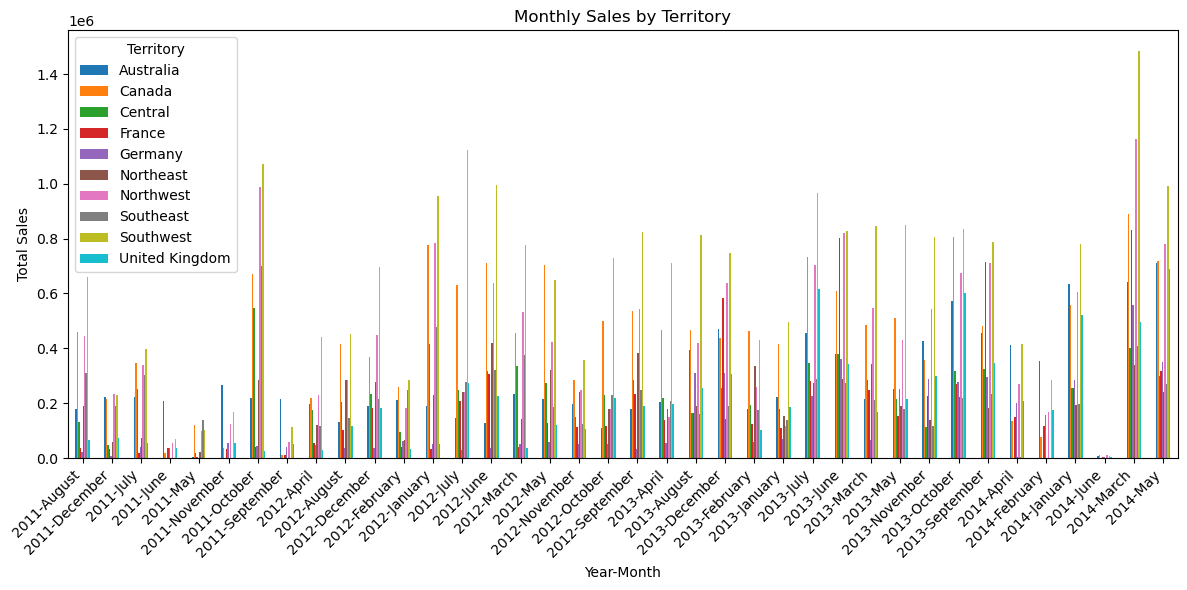

In [88]:
df['YearMonth'] = df['SalesYear'] + "-" + df['SalesMonth']
df_pivot = df.pivot(index='YearMonth', columns='Territory', values='TotalSales').fillna(0)
plt.figure(figsize=(12, 6))
df_pivot.plot(kind='bar', figsize=(12, 6))
plt.title("Monthly Sales by Territory")
plt.xlabel("Year-Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")  
plt.tight_layout()                  
plt.show()

In [89]:
print(inspector.get_table_names(schema='Production'))

['BillOfMaterials', 'Culture', 'Document', 'Illustration', 'Location', 'Product', 'ProductCategory', 'ProductCostHistory', 'ProductDescription', 'ProductDocument', 'ProductInventory', 'ProductListPriceHistory', 'ProductModel', 'ProductModelIllustration', 'ProductModelProductDescriptionCulture', 'ProductPhoto', 'ProductProductPhoto', 'ProductReview', 'ProductSubcategory', 'ScrapReason', 'TransactionHistory', 'TransactionHistoryArchive', 'UnitMeasure', 'WorkOrder', 'WorkOrderRouting']


In [97]:
tables_to_inspect = ['ProductCategory', 'ProductSubcategory']

for tbl in tables_to_inspect:
    print(f"--- Columns for {tbl} ---")
    for col in inspector.get_columns(table_name=tbl, schema='Production'):
        print(col['name'])
    print()

--- Columns for ProductCategory ---
ProductCategoryID
Name
rowguid
ModifiedDate

--- Columns for ProductSubcategory ---
ProductSubcategoryID
ProductCategoryID
Name
rowguid
ModifiedDate



In [ ]:
# Jag ska gå lite djupare på topp 10 mest sålda produkter (efter kvantitet), men inkluderar nu även kategorinamn och underkategorinamn för varje produkt.

In [98]:
query_category_subcategory = """

SELECT TOP 10
    p.ProductID,
    p.Name AS ProductName,
    pc.Name AS CategoryName,
    psc.Name AS SubCategoryName,
    SUM(sod.OrderQty) AS TotalQuantitySold
FROM Sales.SalesOrderDetail sod
JOIN Sales.SalesOrderHeader soh
    ON sod.SalesOrderID = soh.SalesOrderID
JOIN Production.Product p
    ON sod.ProductID = p.ProductID
LEFT JOIN Production.ProductSubcategory psc
    ON p.ProductSubcategoryID = psc.ProductSubcategoryID
LEFT JOIN Production.ProductCategory pc
    ON psc.ProductCategoryID = pc.ProductCategoryID
GROUP BY
    p.ProductID,
    p.Name,
    pc.Name,
    psc.Name
ORDER BY
    SUM(sod.OrderQty) DESC;
"""
df = pd.read_sql(sql=query_category_subcategory, con=connection)
df.head(10)

,ProductID,ProductName,CategoryName,SubCategoryName,TotalQuantitySold
0,712,AWC Logo Cap,Clothing,Caps,8311
1,870,Water Bottle - 30 oz.,Accessories,Bottles and Cages,6815
2,711,"Sport-100 Helmet, Blue",Accessories,Helmets,6743
3,715,"Long-Sleeve Logo Jersey, L",Clothing,Jerseys,6592
4,708,"Sport-100 Helmet, Black",Accessories,Helmets,6532
5,707,"Sport-100 Helmet, Red",Accessories,Helmets,6266
6,864,"Classic Vest, S",Clothing,Vests,4247
7,873,Patch Kit/8 Patches,Accessories,Tires and Tubes,3865
8,884,"Short-Sleeve Classic Jersey, XL",Clothing,Jerseys,3864
9,714,"Long-Sleeve Logo Jersey, M",Clothing,Jerseys,3636


In [1]:
# 2.
# Statistisk analys med konfidensintervall. 
# Först ska jag börja med den här 'query': de 10 bästa produkterna efter TotalQuantitySold tillsammans med den beräknade TotalRevenue.
# Jag ska identifiera vilka produkter som genererar flest beställningar och intäkter.

In [107]:

query_products = """

SELECT TOP 10
    p.ProductID,
    p.Name AS ProductName,
    SUM(sod.OrderQty) AS TotalQuantitySold,
    SUM(sod.UnitPrice * sod.OrderQty) AS TotalRevenue
FROM Sales.SalesOrderDetail sod
JOIN Sales.SalesOrderHeader soh
    ON sod.SalesOrderID = soh.SalesOrderID
JOIN Production.Product p
    ON sod.ProductID = p.ProductID
GROUP BY
    p.ProductID,
    p.Name
ORDER BY
    TotalQuantitySold DESC;
"""

df = pd.read_sql(sql=query_products, con=connection)
df.head(10)

,ProductID,ProductName,TotalQuantitySold,TotalRevenue
0,712,AWC Logo Cap,8311,51512.2811
1,870,Water Bottle - 30 oz.,6815,28732.9689
2,711,"Sport-100 Helmet, Blue",6743,166720.9076
3,715,"Long-Sleeve Logo Jersey, L",6592,200240.7374
4,708,"Sport-100 Helmet, Black",6532,162076.7042
5,707,"Sport-100 Helmet, Red",6266,158865.9084
6,864,"Classic Vest, S",4247,159797.1150
7,873,Patch Kit/8 Patches,3865,8232.9164
8,884,"Short-Sleeve Classic Jersey, XL",3864,130878.2388
9,714,"Long-Sleeve Logo Jersey, M",3636,115509.3736


In [109]:
# Jag ska nu använda intäktsdata från de 10 bästa produkterna för att beräkna sammanfattande statistik och 95 % konfidensintervall 
# för den genomsnittliga ”TotalRevenue”. Eftersom urvalsstorleken är liten (n = 10) använder jag t-fördelningen med 9 frihetsgrader. 
# För en 95 % konfidensnivå är det t-kritiska värdet ungefär 2,262. Då kan jag beräkna medelvärdet, standardavvikelsen och sedan beräkna 
# de nedre och övre gränserna för intervallet.

In [131]:
cte_sql = """

WITH RevenueCTE AS (
    SELECT TOP 10
        p.ProductID,
        p.Name AS ProductName,
        SUM(sod.OrderQty) AS TotalQuantitySold,
        SUM(sod.UnitPrice * sod.OrderQty) AS TotalRevenue
    FROM Sales.SalesOrderDetail sod
    JOIN Sales.SalesOrderHeader soh
        ON sod.SalesOrderID = soh.SalesOrderID
    JOIN Production.Product p
        ON sod.ProductID = p.ProductID
    GROUP BY
        p.ProductID,
        p.Name
    ORDER BY
        TotalQuantitySold DESC
)
SELECT
    ROUND(AVG(TotalRevenue), 2) AS MeanRevenue,
    ROUND(STDEV(TotalRevenue), 2) AS StdRevenue,
    COUNT(*) AS SampleSize,
    -- I calculate the standard error
    ROUND(STDEV(TotalRevenue) / SQRT(CAST(COUNT(*) AS FLOAT)), 2) AS StdError,
    -- The lower bound of the 95% confidence interval using t-critical = 2.262 for df = n - 1 (n = 10)
    ROUND(AVG(TotalRevenue) - 2.262 * (STDEV(TotalRevenue) / SQRT(CAST(COUNT(*) AS FLOAT))), 2) AS LowerCI,
    -- The upper bound of the 95% confidence interval
    ROUND(AVG(TotalRevenue) + 2.262 * (STDEV(TotalRevenue) / SQRT(CAST(COUNT(*) AS FLOAT))), 2) AS UpperCI
FROM RevenueCTE;
   
"""
result = pd.read_sql(cte_sql, engine)
result


,MeanRevenue,StdRevenue,SampleSize,StdError,LowerCI,UpperCI
0,118256.72,65917.85,10,20845.05,71105.2,165408.23


In [130]:
# MeanRevenue: $118256.72
# StdRevenue: $65917.85
# SampleSize: 10
# StdError: ~ $20845.05
# 95% Confidence Interval: [$71105.2, $165408.23]

# Det här betyder att företaget kan  vara 95 % säkra på att den verkliga genomsnittliga intäkten för de mest sålda produkterna 
# ligger mellan cirka 71105.2 USD och  $165408.23 USD. Med andra ord, medan dessa produkter i genomsnitt genererar cirka 118256.72 USD, 
# finns det avsevärd variation i intäkter mellan dem. 

In [3]:
# 3. Analys, slutsatser och rekommendationer. 

# Data Analys: 
#    - De mest sålda produkterna har ett brett utbud av intäkter. Det beräknade konfidensintervallet indikerar att intäkterna för dessa produkter 
#      inte är enhetliga, vilket visar att vissa produkter överträffar andra kraftigt.
#    - Standardfelet indikerar att även om uppskattningen av medelinkomsten är rimligt tillförlitlig, 
#      bör variationen mellan toppprodukter beaktas när beslut fattas.
# Slutsatser:
#    - De mest sålda produkterna är betydande intäktsdrivande, vilket innebär att affärsmodellen drar stor nytta av ett fåtal högpresterande produkter.
#    - Trots att de är bland topp 10 finns det märkbar variation i intäktssiffror. Detta visar att faktorer som prissättning, 
#      marknadsefterfrågan och produktegenskaper kan skilja sig avsevärt mellan dem.
# Rekommendationer:
#    - Undersök i detalj strategierna (t.ex. prissättning, marknadsföring, produktegenskaper) bakom de bäst presterande produkterna 
#      för att replikera deras framgång.
#    - Utöka analysen till större grupper (eller efter produktkategori/underkategori) för att bättre förstå prestanda över hela portföljen, 
#      inte bara bland de bästa produkterna.
#    - Använd den genomsnittliga intäkten tillsammans med variabilitetsinsikter för att förfina lagerplaneringen och allokera marknadsföringsresurser.

In [117]:
# 4. "Executive Summary"

#     1. Jag analyserade data från databasen AdventureWorks2022 med fokus på produktprestanda inom försäljningsdomänen.
#     2. Två T-SQL-frågor användes: en för att lista de 10 bästa produkterna efter såld kvantitet med deras kategorier och underkategorier, 
#        och en annan för att sammanställa intäktssiffror.
#     3. En ytterligare statistisk analys utfördes på intäktsdata för att beräkna den genomsnittliga intäkten 
#        och dess variation bland de mest sålda produkterna.
#     4. Med hjälp av ett urval av 10 toppprodukter uppskattades medelintäkten till cirka 118256.72 USD. 
#     5. Ett konfidensintervall på 95 % beräknades, från ungefär 71105.2 USD USD till 165408.23 USD, vilket indikerar 
#        att den verkliga genomsnittliga intäkten ligger inom detta intervall.
#     6. Min rekommendation är att ytterligare undersöka vad som skiljer de högst presterande och att tillämpa dessa insikter på andra produkter.
#     7. Dessutom kan en utvidgning av analysen över bredare produktsegment avslöja nya möjligheter för tillväxt och effektivitet.
#     8. Sammantaget ger analysen en datadriven grund för att förbättra försäljningsstrategier, optimera lager 
#        och bättre rikta marknadsföringsinsatser för att maximera intäkterna.

In [122]:
# 5. Har spelat in och skickat via Omniway. 

In [5]:
# Teoretiska Frågor

# 1.Beskriv kort hur en relationsdatabas fungerar. 
#       En relationsdatabas lagrar data i väl strukturerade tabeller. Tabellerna kan retalera till varandra med hjälp av främmande nycklar, 
#       som refererar till primärnycklar i andra tabeller, vilket gör att data kan kopplas logiskt. 

# 2.Vad menas med “CRUD”-flödet?
#       CRUD -flödet hänvisar till de fyra grundläggande operationerna (Create, Read, Update, Delete) som vi kan använda för att hantera data 
#       i många applikationer. 

# 3.Beskriv kort vad en “left join” och en “inner join” är. Varför använder man det? 
#       Vi använder ”LEFT JOIN” för att returnera alla rader i den vänstra tabellen. Om det inte finns någon matching returneras NULL. 
#       Vi använder ”INNER JOIN”  för att returnera de rader som matchar i båda tabellerna. Vi använder “JOINS” för att få information från olika rader 
#       och kolumner från flera tabeller. 


# 4.Beskriv kort vad indexering i SQL innebär. 
#       Det är en specialiserad datastruktur som till exempel ett B-träd eller hash-baserad struktur som kan hjälpa till 
#       att påskynda datahämtningen i en databastabell.

# 5.Beskriv kort vad en vy i SQL är.
#       En vy är en tabell där själva innehållet bestäms av en “query”. 

# 6.Beskriv kort vad en lagrad procedur i SQL är.
#       Det är koden som är ”lagrad ”, ” sparad” och sen kan man återanvända den. 


In [6]:
# Självvärdering

# Efter att du är klar skall du även skriva en kort redogörelse i slutet av rapporten där du beskriver: 
# 1.Utmaningar du haft under arbetet samt hur du hanterat dem. 
#     Eftersom att jag aldrig har arbetat med detta tidigare så var det mycket ny info och mycket nytt att lära mig från grunden.
#     Det var lite svårt i början när jag skulle integrera Python och biblioteket SQLAlchemy med SQL. Dock hjälpte det mycket att kolla flera gånger på
#     videon om SQLAlchemy och MSSQL.

# 2.Vilket betyg du anser att du skall ha och varför
#     För mig spelar det ingen roll. Mitt fokus är på att lära mig och att få en bra grund i SQL. 

# 3.Tips du hade gett till dig själv i början av kursen nu när du slutfört den.
#     Jag hade givit mig själv tips att ta mig tid att verkligen sätta mig in i grunderna och gjort fler övningar. 
#     Detta är något jag måste fortsätta att öva på. 
